In [9]:
import os

from dotenv import load_dotenv

load_dotenv()



True

In [2]:
%load_ext autoreload
%autoreload 2

## 上下文隔离：子代理

<img src="./resources/agent_header_subagent.png" width="800" style="display:block; margin-left:0;">

随着对话的进行，代理上下文会迅速增长，导致多个与长上下文相关的问题。一个主要问题是上下文冲突或混淆，即同一上下文窗口中的混合目标可能导致次优性能。[上下文隔离](https://blog.langchain.com/context-engineering-for-agents/)通过将任务委派给[专门的子代理](https://www.anthropic.com/engineering/multi-agent-research-system)提供了一个有效的解决方案，每个子代理都在其自己隔离的上下文窗口中运行。这种方法可以防止上下文冲突、混淆、污染和稀释，同时实现专注的、专业化的任务执行。



### 子代理委派
![./resources/subagents.png](./resources/subagents.png)

核心思路是我们可以创建具有针对不同任务定制的不同工具集的子代理。每个子代理都以 `subagent_type` 为键存储在注册表字典中，允许主代理通过 `task(description, subagent_type)` 工具调用委派工作。子代理与父代理的上下文完全隔离运行，其结果作为 `ToolMessage` 返回给父代理，保持清晰的关注点分离。


<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>注意：</b>  
<code>create_react_agent</code> 在 1.0 版本代码发布（拍摄后）已从 LangGraph 库移至 LangChain 库，并重命名为 <code>create_agent</code>。为此，导入和代码有细微调整。视频可能显示之前的配置。
</div>

**加载环境变量**：参考第一个模块中的 "环境配置" 部分。`dotenv` [文档](https://pypi.org/project/python-dotenv/) 会查找 `../.env` 文件。如果找到该文件，将从中加载环境变量，覆盖当前终端中的已有变量；如果未找到，则使用当前终端中的环境变量。

让我们定义用户将如何指定子代理
```python
from typing_extensions import TypedDict

class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str     ## used by main agent
    description: str  ## used by main agent
    prompt: str    # define sub agent
    tools: NotRequired[list[str]]   # define sub agent tools
```

我们将使用这些对象的列表来创建所有可用的子代理

```python
agents: list[SubAgent] = ...
subagents = {
    agent['name']: create_react_agent(
        model=model,
        prompt=agent['prompt'],
        tools = get_tools(agent['tools']),
        ...
    )
}
```

## Step 2: Create a tool to use Sub Agents

Logically, should look something like:

```python
def task(
    description: str  # 子代理应该执行的任务
    subagent_type: str  # 要使用的子代理类型
):
    # 创建新消息传递给子代理 - 应该只有描述
    # 调用子代理
    # 用子代理的响应以及文件系统的任何更改来更新状态
```

完整的代码如下：

```python
@tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
def task(
    description: str,
    subagent_type: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
):
    """将任务委托给具有隔离上下文的专门子代理。

    这为子代理创建了一个仅包含任务描述的全新上下文，
    防止父代理对话历史造成的上下文污染。
    """
    # 验证请求的代理类型是否存在
    if subagent_type not in agents:
        return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

    # 获取请求的子代理
    sub_agent = agents[subagent_type]

    # 创建仅包含任务描述的隔离上下文
    # 这是上下文隔离的关键 - 不包含父代理历史记录
    state["messages"] = [{"role": "user", "content": description}]

    # 在隔离环境中执行子代理
    result = sub_agent.invoke(state)

    # 通过 Command 状态更新将结果返回给父代理
    return Command(
        update={
            "files": result.get("files", {}),  # Merge any file changes
            "messages": [
                # Sub-agent result becomes a ToolMessage in parent context
                ToolMessage(
                    result["messages"][-1].content, tool_call_id=tool_call_id
                )
            ],
        }
    )

return task
```

In [3]:
%%writefile ../../src/deep_agents_from_scratch/task_tool.py
"""Task delegation tools for context isolation through sub-agents.

This module provides the core infrastructure for creating and managing sub-agents
with isolated contexts. Sub-agents prevent context clash by operating with clean
context windows containing only their specific task description.
"""

from typing import Annotated, NotRequired
from typing_extensions import TypedDict

from langchain_core.messages import ToolMessage
from langchain_core.tools import BaseTool, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState  # updated 1.0
from langchain.agents import create_agent  # updated 1.0

from langgraph.types import Command

from deep_agents_from_scratch.prompts import TASK_DESCRIPTION_PREFIX
from deep_agents_from_scratch.state import DeepAgentState


class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """Create a task delegation tool that enables context isolation through sub-agents.

    This function implements the core pattern for spawning specialized sub-agents with
    isolated contexts, preventing context clash and confusion in complex multi-step tasks.

    Args:
        tools: List of available tools that can be assigned to sub-agents
        subagents: List of specialized sub-agent configurations
        model: The language model to use for all agents
        state_schema: The state schema (typically DeepAgentState)

    Returns:
        A 'task' tool that can delegate work to specialized sub-agents
    """
    # Create agent registry
    agents = {}

    # Build tool name mapping for selective tool assignment
    tools_by_name = {}
    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    # Create specialized sub-agents based on configurations
    for _agent in subagents:
        if "tools" in _agent:
            # Use specific tools if specified
            _tools = [tools_by_name[t] for t in _agent["tools"]]
        else:
            # Default to all tools
            _tools = tools
        agents[_agent["name"]] = create_agent(   # updated 1.0
            model, system_prompt=_agent["prompt"], tools=_tools, state_schema=state_schema
        )

    # Generate description of available sub-agents for the tool description
    other_agents_string = [
        f"- {_agent['name']}: {_agent['description']}" for _agent in subagents
    ]

    @tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
    def task(
        description: str,
        subagent_type: str,
        state: Annotated[DeepAgentState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """Delegate a task to a specialized sub-agent with isolated context.

        This creates a fresh context for the sub-agent containing only the task description,
        preventing context pollution from the parent agent's conversation history.
        """
        # Validate requested agent type exists
        if subagent_type not in agents:
            return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

        # Get the requested sub-agent
        sub_agent = agents[subagent_type]

        # Create isolated context with only the task description
        # This is the key to context isolation - no parent history
        state["messages"] = [{"role": "user", "content": description}]

        # Execute the sub-agent in isolation
        result = sub_agent.invoke(state)

        # Return results to parent agent via Command state update
        return Command(
            update={
                "files": result.get("files", {}),  # Merge any file changes
                "messages": [
                    # Sub-agent result becomes a ToolMessage in parent context
                    ToolMessage(
                        result["messages"][-1].content, tool_call_id=tool_call_id
                    )
                ],
            }
        )

    return task

Overwriting ../../src/deep_agents_from_scratch/task_tool.py


现在，您有了一个可以将子代理生成为工具的例程。现在，您可以定义特定的子代理，并允许系统使用 `task` 工具调用它们。  
在上面，`_create_task_tool` 接收一个类型为 `SubAgent` 的列表。该列表包含要创建的代理的描述。

```python
class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """Create a task delegation tool that enables context isolation through sub-agents.

```
`SubAgent` 类定义了满足子代理双重角色所需的独特信息。子代理既是工具也是代理。

- **作为工具**，它们为主管代理提供有关其能力以及如何调用它们的信息。
- **作为代理**，它们需要一个描述如何执行任务的提示词，以及一组针对这些任务的工具。

下面，您将创建一个研究子代理。它的 `description` 告知主管代理应将单个任务委托给此子代理。`SIMPLE_RESEARCH_INSTRUCTIONS` 是子代理用于指导其研究的提示词。在此示例中，它很简短，但对于通用研究者来说，它可以更加详细。子代理还配备了一个 `web_search` 工具，用于在其研究期间使用。
```python
# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}
```

请注意，子代理会接收一个特定的任务，以及完成该任务所需的工具。它在自己的上下文中运行，仅限于单个任务描述。这种[上下文工程](https://blog.langchain.com/context-engineering-for-agents/)方法确保子代理的工作上下文不会出现上下文冲突、混淆、污染或稀释。

主管代理的提示词现在必须包含如何调用和使用这些子代理的描述。如下所示。请注意*可用工具*的描述以及关于在适用情况下使用并行研究的说明。


In [4]:
from utils import show_prompt

from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS

show_prompt(SUBAGENT_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your role is to coordinate research by delegating specific research tasks to sub-agents.                       │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: Delegate research tasks to specialized sub-agents                     │
│     - description: Clear, specific research question or task                                                    │
│     - subagent_type: Type of agent to use (e.g., "research-agent")                                              │
│  2. **think_tool(reflection)**: Reflect on the results of each delegated task and plan next steps.              │
│     - reflection: Your detailed reflection on the results of the task and next steps.                           │
│                                                                                                                 │
│  **PARALLEL RESEARCH**: When you identify multiple independent research directions, make multiple **task**      │
│  tool calls in a single response to enable parallel execution. Use at most {max_concurrent_research_units}      │
│  parallel agents per iteration.                                                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Task Delegation Budgets** (Prevent excessive delegation):                                                    │
│  - **Bias towards focused research** - Use single agent for simple questions, multiple only when clearly        │
│  beneficial or when you have multiple independent research directions based on the user's request.              │
│  - **Stop when adequate** - Don't over-research; stop when you have sufficient information                      │
│  - **Limit iterations** - Stop after {max_researcher_iterations} task delegations if you haven't found          │
│  adequate sources                                                                                               │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **Simple fact-finding, lists, and rankings** can use a single sub-agent:                                       │
│  - *Example*: "List the top 10 coffee shops in San Francisco" → Use 1 sub-agent, store in                       │
│  `findings_coffee_shops.md`                                                                                     │
│                                                                                                                 │
│  **Comparisons** can use a sub-agent for each element 

现在我们来构建一个带有监督者和子代理的研究系统。这只是一个模拟版本，使用预定义的搜索结果来演示各个部分如何组合在一起。在下一课中，你将构建一个完整的研究系统。


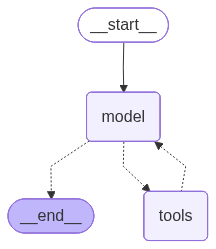

In [5]:
from datetime import datetime

from IPython.display import Image, display
import os
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent # updated in 1.0

from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Mock search result
search_result = """模型上下文协议（MCP）是由Anthropic开发的开放标准协议，旨在实现AI模型与外部系统（如工具、数据库和其他服务）之间的无缝集成。它充当标准化的通信层，使AI模型能够以一致且高效的方式访问和利用来自各种来源的数据。本质上，MCP通过为数据交换提供统一的语言，简化了将AI助手连接到外部服务的过程。"""


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from the search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """你是一个研究员。研究提供给你的主题。重要提示：只需对web_search工具进行一次调用，并使用工具返回的结果来回答提供的主题。"""

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "将研究任务委托给子代理研究员。一次只给这位研究员一个主题。",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}

# Create agent using create_react_agent directly
# model = init_chat_model(
#     model="deepseek-chat",  
#     temperature=0.0,
# )
model = init_chat_model(
    model="agnes-2.0-flash",
    model_provider="openai",
    base_url=os.getenv("AGNES_BASE_URL"),
    api_key=os.getenv("AGNES_API_KEY"),
        temperature=0.0,
)
# Tools for sub-agent
sub_agent_tools = [web_search]

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

# Tools
delegation_tools = [task_tool]

# Create agent with system prompt
agent = create_agent(
    model,
    delegation_tools,
    system_prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
        date=datetime.now().strftime("%a %b %-d, %Y"),
    ),
    state_schema=DeepAgentState,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [6]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "请给我一个关于MCP的概述。",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 请给我一个关于MCP的概述。                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "请提供关于MCP（Model Context                                                                  │
│ Protocol）的全面概述，包括：1）MCP是什么，由谁开发；2）MCP的主要功能和用途；3）MCP的架构和工作原理；4）MCP的优  │
│ 势和局限性；5）MCP在AI生态系统中的应用场景；6）MCP与其他类似协议（如OpenAPI、GraphQL等）的比较。请提供最新的信  │
│ 息。",                                                                                                          │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: chatcmpl-tool-99b5d4e3eb8e57e4                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 基于搜索结果，以下是关于 **MCP（Model Context Protocol，模型上下文协议）** 的全面概述：                         │
│                                                                                                                 │
│ ### 1) MCP 是什么，由谁开发？                                                                                   │
│ *   **定义**：MCP（Model Context Protocol，模型上下文协议）是一个开放的标准化协议。                             │
│ *   **开发者**：由 **Anthropic** 开发。                                                                         │
│ *   **核心目的**：旨在解决 AI 模型（特别是大型语言模型                                                          │
│ LLMs）与外部数据源、工具和服务之间连接复杂的问题。它提供了一个统一的接口，让 AI                                 │
│ 能够安全、标准化地访问外部资源。                                                                                │
│                                                                                                                 │
│ ### 2) MCP 的主要功能和用途                                                                                     │
│ *   **标准化连接**：为 AI 应用与外部系统（如数据库、文件系统、API、企业内部工具）之间的通信提供统一的标准。     │
│ *   **上下文注入**：允许 AI 模型在推理过程中动态获取最新的、实时的外部数据，而不仅仅依赖训练数据。              │
│ *   **工具调用标准化**：简化了 AI 模型调用外部工具（如搜索、计算、代码执行）的过程，确保不同平台间的兼容性。    │
│ *   **降低集成成本**：开发者只需按照 MCP 标准构建一次“连接器”或“服务器”，即可被任何支持 MCP 的 AI               │
│ 客户端使用，无需为每个 AI 平台单独开发接口。                                                                    │
│                                                                                                                 │
│ ### 3) MCP 的架构和工作原理                                                                                     │
│ MCP 通常采用 **客户端-服务器（Client-Server）** 架构：                                                          │
│ *   **MCP Host（主机/客户端）**：通常是 AI 应用本身（如 Claude Desktop、Cursor、VS Code                         │
│ 插件等），它发起请求并消费数据。                                                                                │
│ *   **MCP Server（服务器）**：托管在外部系统上，负责暴露数据、工具或功能。它遵循 MCP                            │
│ 协议，向客户端提供标准化的接口。                                                                                │
│ *   **通信机制**：                                                                                              │
│     *   支持多种传输方式，最常见的是 **stdio**（标准输入输出，用于本地进程间通信）和                            │
│ **HTTP/SSE**（用于远程服务）。                                                                                  │
│     *   使用 JSON-RPC 2.0 作为消息格式，确保轻量级和跨平台兼容性。                                              │
│ *   **工作流程**：                                                                                              │
│     1.  客户端启动并发现可用的 MCP 服务器。                                                                     │
│     2.  客户端向服务器发送请求（如“获取某数据库的最新记录”或“执行某个工具”）。                                  │
│     3.  服务器处理请求，从后端系统获取数据或执行操作。                                                          │
│     4.  服务器将结果以结构化数据形式返回给客户端。                                                              │
│     5.  客户端将数据注入到 AI 模型的上下文中，供其生成响应。                                                    │
│                                                                                                                 │
│ ### 4) MCP 的优势和局限性                                                                                       │
│ **优势：**                                                                                                      │
│ *   **互操作性**：打破“孤岛”，使不同 AI 平台能共享相同的工具和数据来源。                                        │
│ *   **安全性**：通过明确的权限控制和数据边界，比直接开放 API 更可控。                                           │
│ *   **开发者友好**：减少重复开发工作，加速 AI 应用的集成速度。                                                  │
│ *   **实时性**：使 AI 能够访问最新数据，克服模型训练数据过时的问题。                                            │
│                                                                                                                 │
│ **

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## MCP（Model Context Protocol）概述                                                                            │
│                                                                                                                 │
│ ### 1. 什么是 MCP？                                                                                             │
│ **MCP（Model Context Protocol，模型上下文协议）** 是由 **Anthropic**                                            │
│ 开发的一个开放标准化协议。它的核心目的是解决 AI 模型（特别是大语言模型                                          │
│ LLMs）与外部数据源、工具和服务之间连接复杂的问题，提供一个统一的接口让 AI 能够安全、标准化地访问外部资源。      │
│                                                                                                                 │
│ ### 2. 主要功能和用途                                                                                           │
│ - **标准化连接**：为 AI 应用与外部系统（数据库、文件系统、API、企业内部工具）之间的通信提供统一标准。           │
│ - **上下文注入**：允许 AI 模型在推理过程中动态获取实时外部数据，克服训练数据过时的问题。                        │
│ - **工具调用标准化**：简化 AI 模型调用外部工具（搜索、计算、代码执行等）的过程，确保跨平台兼容性。              │
│ - **降低集成成本**：开发者只需按 MCP 标准构建一次"连接器"，即可被任何支持 MCP 的 AI 客户端使用。                │
│                                                                                                                 │
│ ### 3. 架构和工作原理                                                                                           │
│ MCP 采用 **客户端-服务器（Client-Server）** 架构：                                                              │
│ - **MCP Host（客户端）**：AI 应用本身（如 Claude Desktop、Cursor、VS Code 插件等）                              │
│ - **MCP Server（服务器）**：托管在外部系统上，暴露数据、工具或功能                                              │
│ - **通信机制**：支持 stdio（本地进程间通信）和 HTTP/SSE（远程服务），使用 JSON-RPC 2.0 消息格式                 │
│                                                                                                                 │
│ ### 4. 优势与局限性                                                                                             │
│ **优势：**                                                                                                      │
│ - 互操作性强，打破"孤岛"                                                                                        │
│ - 安全性高，有明确的权限控制                                                                                    │
│ - 开发者友好，减少重复开发                                                                                      │
│ - 支持实时数据访问                                                                                              │
│                                                                                                                 │
│ **局限性：**                                                                                                    │
│ - 作为较新的协议，生态仍在发展中                                                                                │
│ - 可能引入通信延迟                                                                                              │
│ - 简单任务下可能显得过重                                                                                        │
│ - 配置不当可能存在安全风险                                                                                      │
│                                                                                                                 │
│ ### 5. 应用场景                                                                                                 │
│ - **企业知识库查询**：连接内部文档、Confluence 等                                                               │
│ - **开发辅助**：IDE 插件连接代码库、Git 仓库、CI/CD 管道                                                        │
│ - **数据分析**：直接查询 SQL 数据库、数据仓库                                                                   │
│ - **个人助理**：连接日历、邮件、待办事项应用                                                                    │
│ - **多步骤自动化**：调用多个工具完成复杂工作流                                                                  │
│                                      

### Streaming Agent Execution

Stream the agent to see sub-agent delegation in real-time:



In [7]:
from utils import stream_agent
import asyncio

# This shows sub-agent calls with graph/node names
await stream_agent(
    agent,
    {"messages": [{"role": "user", "content": "请给我一个关于MCP的概述。"}]},
)

Graph: root
Node: model


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "请提供关于MCP（Model Context Protocol）的全面概述，包括：1. MCP的定义和基本概念 2.            │
│ 主要特点和功能 3. 架构组成（Host、Client、Server等） 4. 使用场景和应用案例 5.                                   │
│ 与其他类似协议（如OpenAPI、GraphQL等）的对比 6. 当前的发展状态和社区支持",                                      │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: chatcmpl-tool-96a790f1684540e0                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Graph: ('tools:87f14a4b-3c6c-fa8f-b19c-10c3ea21da70',)
Node: model


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "MCP Model Context Protocol overview architecture features use cases comparison"                     │
│ }                                                                                                               │
│    ID: chatcmpl-tool-857c7ea7d760cca3                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Graph: ('tools:87f14a4b-3c6c-fa8f-b19c-10c3ea21da70',)
Node: tools


...

Graph: root
Node: tools


╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 基于搜索结果，以下是关于 **MCP（Model Context Protocol，模型上下文协议）** 的全面概述：                         │
│                                                                                                                 │
│ ### 1. MCP 的定义和基本概念                                                                                     │
│ **MCP（Model Context Protocol）** 是由 **Anthropic** 开发的一种开放标准协议。其核心目的是解决 AI                │
│ 模型（特别是大型语言模型，LLM）与外部数据源、工具和服务之间集成复杂的问题。                                     │
│                                                                                                                 │
│ *   **基本概念**：MCP 充当一个标准化的“通信层”或“中间件”。它允许 AI                                             │
│ 应用以统一、一致的方式连接到各种外部系统（如数据库、文件系统、API                                               │
│ 服务等），而无需为每个外部服务编写定制的集成代码。                                                              │
│ *   **核心目标**：简化 AI 助手与外部世界交互的过程，实现“一次连接，处处可用”的互操作性。                        │
│                                                                                                                 │
│ ### 2. 主要特点和功能                                                                                           │
│ *   **标准化接口**：提供统一的客户端-服务器架构，定义了一套标准的 JSON-RPC                                      │
│ 消息格式，用于描述工具、资源和提示词。                                                                          │
│ *                                                                                                               │
│ **动态发现**：支持客户端动态发现服务器提供的工具（Tools）、资源（Resources）和提示词模板（Prompts），无需硬编码 │
│ 。                                                                                                              │
│ *   **上下文注入**：允许 AI 模型在推理过程中实时获取最新的外部数据，增强其回答的准确性和时效性。                │
│ *   **安全性与权限控制**：设计时考虑了安全边界，支持对数据访问和工具执行的权限管理。                            │
│ *   **跨平台兼容**：旨在成为跨不同 AI 框架、模型提供商和开发语言的通用协议。                                    │
│                                                                                                                 │
│ ### 3. 架构组成                                                                                                 │
│ MCP 采用经典的 **客户端-服务器（Client-Server）** 架构，主要包含以下组件：                                      │
│                                                                                                                 │
│ *   **Host（主机/应用）**：                                                                                     │
│     *   这是最终用户运行的应用程序（如 Claude Desktop、Cursor、VS Code 插件等）。                               │
│     *   Host 包含 **MCP Client**，负责发起请求、管理会话并呈现结果给用户。                                      │
│ *   **Client（客户端）**：                                                                                      │
│     *   嵌入在 Host 应用中，负责与 MCP Server 建立连接、发送请求（如调用工具、读取资源）并解析响应。            │
│ *   **Server（服务器）**：                                                                                      │
│     *   运行在外部数据源或服务端（如数据库服务器、文件系统服务、内部 API 网关）。                               │
│     *   实现 MCP 协议，向 Client 暴露其能力（如“我可以查询 PostgreSQL 数据库”或“我可以读取本地文件”）。         │
│     *   每个 Server 专注于特定领域或数据源。                                                                    │
│                                                                                                                 │
│ **通信流程**：                                                                                                  │
│ 1.  Host 启动，Client 初始化并连接到指定的 MCP Server。                                                         │
│ 2.  Client 请求 Server 列出可用的工具、资源和提示词。                                                           │
│ 3.  当用户提出请求时，Host 决定调用哪个工具。                                                                   │
│ 4.  Client 向 Server 发送工具调用请求。                                                                         │
│ 5.  Server 执行操作（如查询数据库），并将结果返回给 Client。                  

Graph: root
Node: model


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## MCP（Model Context Protocol）概述                                                                            │
│                                                                                                                 │
│ **MCP（Model Context Protocol，模型上下文协议）** 是由 **Anthropic** 开发的一种开放标准协议，旨在解决 AI        │
│ 模型与外部数据源、工具和服务之间的集成问题。                                                                    │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 1. 核心概念                                                                                                 │
│                                                                                                                 │
│ MCP 充当一个标准化的"通信层"或"中间件"，允许 AI                                                                 │
│ 应用以统一、一致的方式连接到各种外部系统（如数据库、文件系统、API                                               │
│ 服务等），实现"一次连接，处处可用"的互操作性。                                                                  │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 2. 架构组成                                                                                                 │
│                                                                                                                 │
│ MCP 采用 **客户端-服务器（Client-Server）** 架构：                                                              │
│                                                                                                                 │
│ | 组件 | 说明 |                                                                                                 │
│ |------|------|                                                                                                 │
│ | **Host（主机）** | 最终用户运行的应用程序（如 Claude Desktop、Cursor、VS Code 插件等） |                      │
│ | **Client（客户端）** | 嵌入在 Host 中，负责与 Server 建立连接、发送请求并解析响应 |                           │
│ | **Server（服务器）** | 运行在外部数据源或服务端，向 Client 暴露其能力（如工具、资源、提示词） |               │
│                                                                                                                 │
│ **工作流程**：Host 启动 → Client 连接 Server → 动态发现可用工具 → 用户请求 → Client 调用 Server → 返回结果给 AI │
│ 模型                                                                                                            │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 3. 主要特点                                                                                                 │
│                                                                                                                 │
│ - **标准化接口**：统一的 JSON-RPC 消息格式                                                                      │
│ - **动态发现**：客户端可动态发现服务器提供的工具、资源和提示词                                                  │
│ - **上下文注入**：AI 模型在推理过程中实时获取外部数据                                                           │
│ - **安全与权限控制**：支持数据访问和工具执行的权限管理                                                          │
│ - **跨平台兼容**：支持不同 AI 框架、模型提供商和开发语言                               

{'messages': [HumanMessage(content='请给我一个关于MCP的概述。', additional_kwargs={}, response_metadata={}, id='83889f76-ab32-4d2a-9760-84535a39eea7'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 1057, 'total_tokens': 1172, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'agnes-2.0-flash', 'system_fingerprint': 'vllm-0.21.0-tp2-52bef988', 'id': 'chatcmpl-bc7783a06c0c235a', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ebd07-a6ee-78f2-ba0a-a3467e008afe-0', tool_calls=[{'name': 'task', 'args': {'description': '请提供关于MCP（Model Context Protocol）的全面概述，包括：1. MCP的定义和基本概念 2. 主要特点和功能 3. 架构组成（Host、Client、Server等） 4. 使用场景和应用案例 5. 与其他类似协议（如OpenAPI、GraphQL等）的对比 6. 当前的发展状态和社区支持', 'subagent_type': 'research-agent'}, 'id': 'chatcmpl-tool-96a790f1684540e0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1057, 'o

Trace: 
https://smith.langchain.com/public/26cc1c2b-e785-4c6d-a2a7-c30a31875fc7/r
<!-- https://smith.langchain.com/public/edc4e672-db9c-457a-953d-f62e7813591c/r -->